# Spam Email Detection using Naive Bayes

In [ ]:
# This project uses Natural Language Processing (NLP) and the Naive Bayes algorithm to classify messages as spam or ham.

In [146]:
# Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [147]:
# Dataset

df= pd.read_csv("emails.csv")

In [12]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [13]:
df.shape

(5728, 2)

In [14]:
df.columns

Index(['text', 'spam'], dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [16]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(33)

In [18]:
df=df.drop_duplicates(keep='first')

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.shape

(5695, 2)

# Checking the spam and ham distribution

In [21]:
df['spam'].value_counts()

spam
0    4327
1    1368
Name: count, dtype: int64

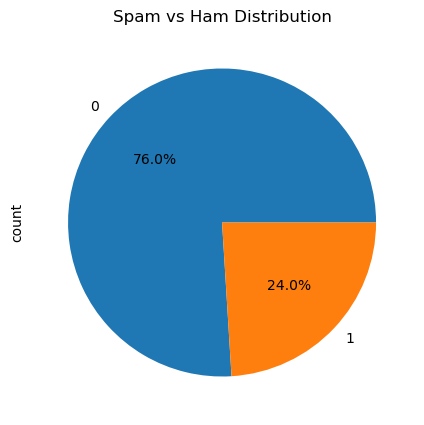

In [22]:
plt.figure(figsize=(5,5))

df['spam'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title("Spam vs Ham Distribution")

plt.show()

# Featuring Engineering

In [23]:
df['num_characters'] = df['text'].apply(len)

In [24]:
df['num_words']= df['text'].apply(lambda x: len(x.split()))

In [25]:
import nltk

In [26]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kshit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [27]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [28]:
df.head()

,text,spam,num_characters,num_words,num_sentences
0,Subject: naturally irresistible your corporate...,1,1484,324,11
1,Subject: the stock trading gunslinger fanny i...,1,598,89,1
2,Subject: unbelievable new homes made easy im ...,1,448,87,4
3,Subject: 4 color printing special request add...,1,500,98,5
4,"Subject: do not have money , get software cds ...",1,235,52,9


# Exploratory Data Analysis
comparing spam and ham messages based on text statistics.

In [30]:
df.groupby('spam')[['num_characters','num_words','num_sentences']].mean()

,num_characters,num_words,num_sentences
spam,,,
0,1634.200139,346.253293,19.838225
1,1317.257310,266.432749,18.274123


In [56]:
df[df["spam"]==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,1368.000000,1368.000000,1368.000000
mean,1317.257310,266.432749,18.274123
std,2271.372893,451.461674,28.130434
min,18.000000,4.000000,1.000000
25%,401.500000,79.000000,6.000000
50%,693.500000,139.500000,11.000000
75%,1250.250000,251.000000,18.000000
max,28432.000000,6129.000000,438.000000


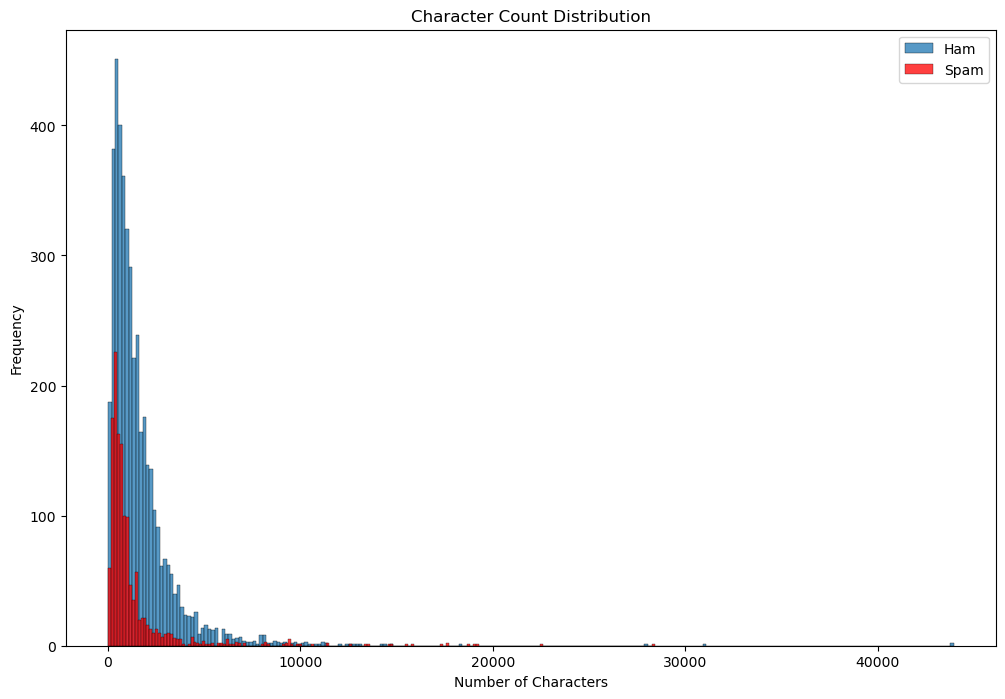

In [59]:
plt.figure(figsize=(12,8))

sns.histplot(df[df["spam"] == 0]["num_characters"],label="Ham")

sns.histplot(df[df["spam"] == 1]["num_characters"],color="red",label="Spam")

plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.title("Character Count Distribution")

plt.legend()

plt.show()

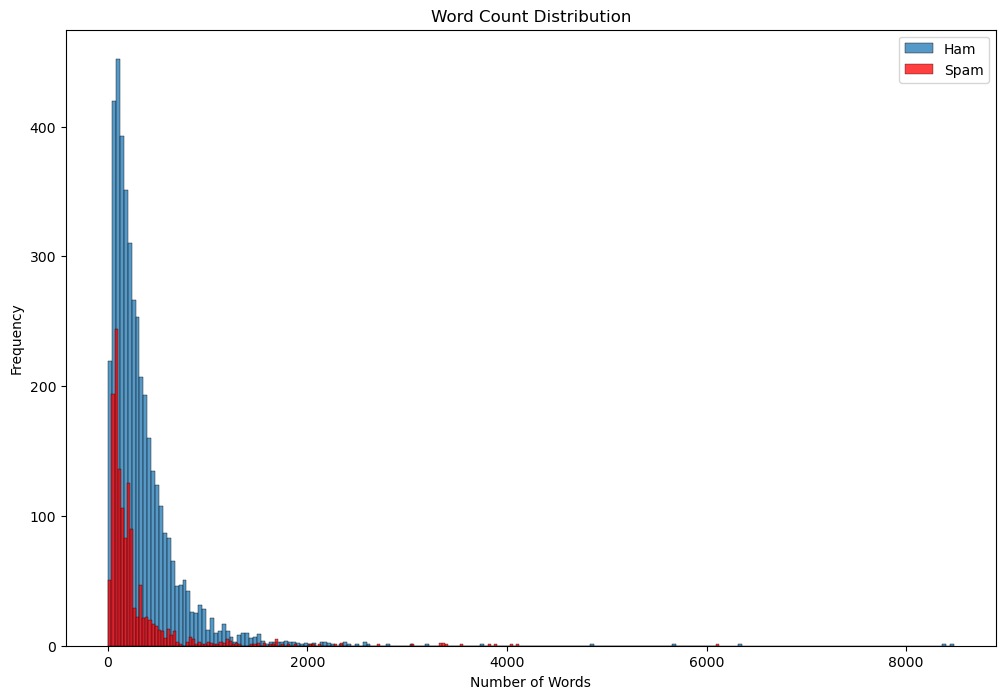

In [60]:
plt.figure(figsize=(12,8))

sns.histplot(df[df["spam"] == 0]["num_words"],label="Ham")

sns.histplot(df[df["spam"] == 1]["num_words"],color="red",label="Spam")

plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.title("Word Count Distribution")

plt.legend()

plt.show()

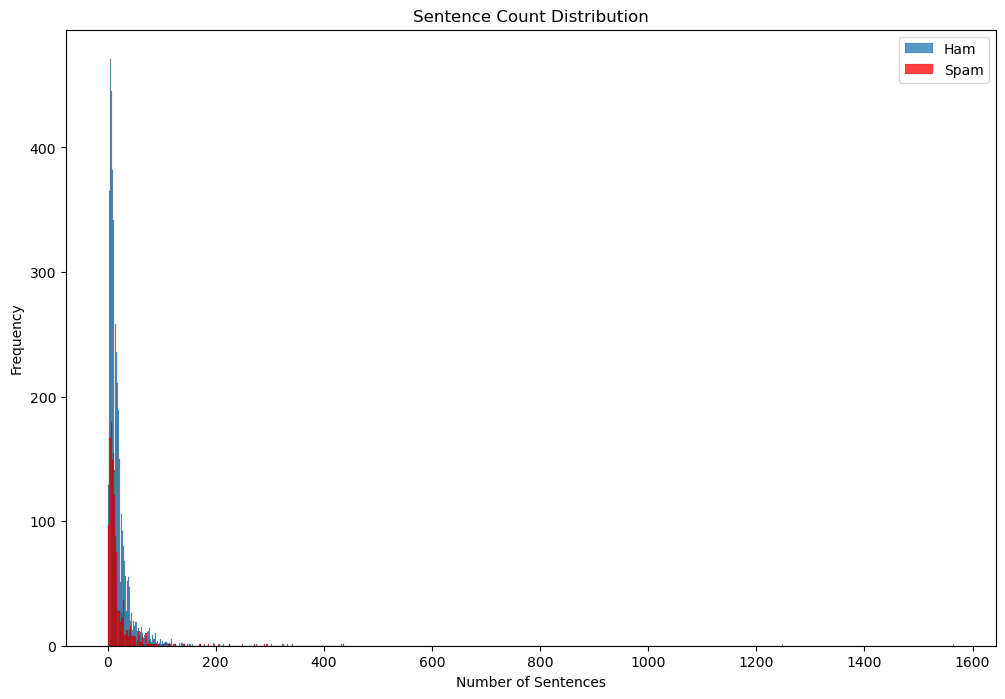

In [61]:
plt.figure(figsize=(12,8))

sns.histplot(df[df["spam"] == 0]["num_sentences"],label="Ham")

sns.histplot(df[df["spam"] == 1]["num_sentences"],color="red",label="Spam")

plt.xlabel("Number of Sentences")
plt.ylabel("Frequency")

plt.title("Sentence Count Distribution")

plt.legend()

plt.show()

In [ ]:
# Visualizing the relationship between different numerical features.

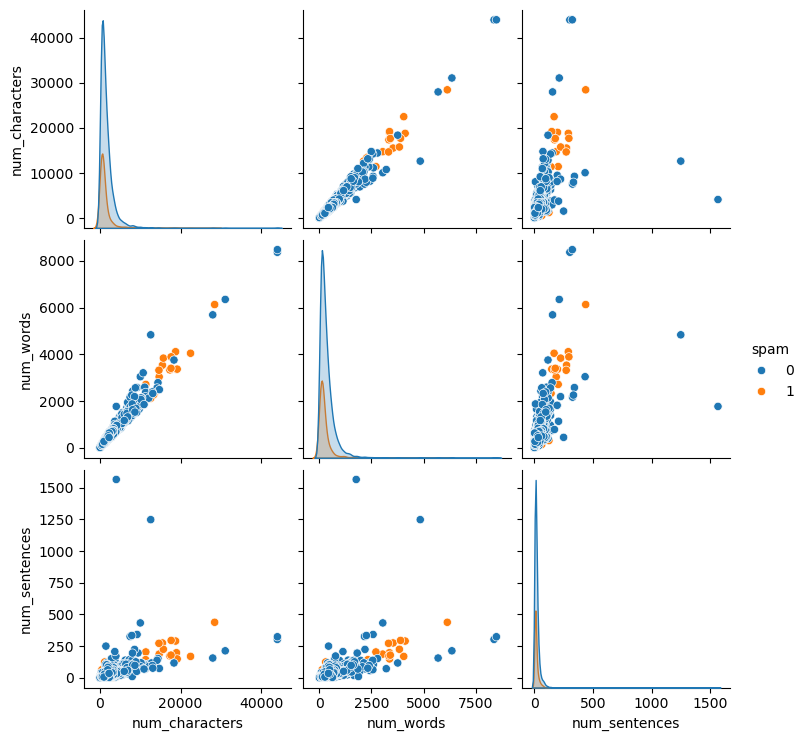

In [62]:
sns.pairplot(df, hue='spam')

# Text Preprocessing
The text is cleaned using:

Lowercasing,
Tokenization,
Removing stopwords,
Removing punctuation,
Stemming,

In [31]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string

In [32]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kshit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [34]:
ps= PorterStemmer()

In [36]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [149]:
# creating text transformation function

In [37]:
def transform_text(text):

    #lowercasing
    text = text.lower()

    # tokenize
    text= nltk.word_tokenize(text)

    y=[]

    # removing special characters
    for i in text:
        if i.isalnum():
            y.append(i)

    text= y[:]
    y.clear()

    # removing stopwords
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text= y[:]
    y.clear()

    # stemming
    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)


# Applying Text Preprocessing

In [40]:
df['transformed_text'] = df['text'].apply(transform_text)

In [41]:
df.head()

,text,spam,num_characters,num_words,num_sentences,transformed_text
0,Subject: naturally irresistible your corporate...,1,1484,324,11,subject natur irresist corpor ident lt realli ...
1,Subject: the stock trading gunslinger fanny i...,1,598,89,1,subject stock trade gunsling fanni merril muzo...
2,Subject: unbelievable new homes made easy im ...,1,448,87,4,subject unbeliev new home made easi im want sh...
3,Subject: 4 color printing special request add...,1,500,98,5,subject 4 color print special request addit in...
4,"Subject: do not have money , get software cds ...",1,235,52,9,subject money get softwar cd softwar compat gr...


In [44]:
# Comparing original vs processed text

print(df['text'][0])

print()

print(df['transformed_text'][0])

Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good products , effective business organization and practicable aim it  will be hotat nowadays market ; but we do promise that your marketing efforts  will become much more effective . here is the list of clear  benefits : creativeness : hand - made , original logos , specially done  to reflect your distinctive company image . convenience : logo and stationery  are provided in all formats ; easy - to - use content management system letsyou  change your website content and even its structure . promptness : you  will see logo drafts within three business days . affordability : your  mar

# WordCloud Visualization

In [45]:
from wordcloud import WordCloud

In [46]:
spam_words = []

for msg in df[df['spam'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_words.append(word)

In [47]:
from collections import Counter

Counter(spam_words).most_common(20)

[('subject', 1577),
 ('compani', 1065),
 ('com', 1000),
 ('1', 952),
 ('mail', 917),
 ('busi', 897),
 ('email', 865),
 ('inform', 818),
 ('receiv', 727),
 ('e', 701),
 ('get', 694),
 ('5', 687),
 ('money', 662),
 ('pleas', 619),
 ('2', 613),
 ('free', 606),
 ('3', 604),
 ('make', 603),
 ('http', 603),
 ('market', 600)]

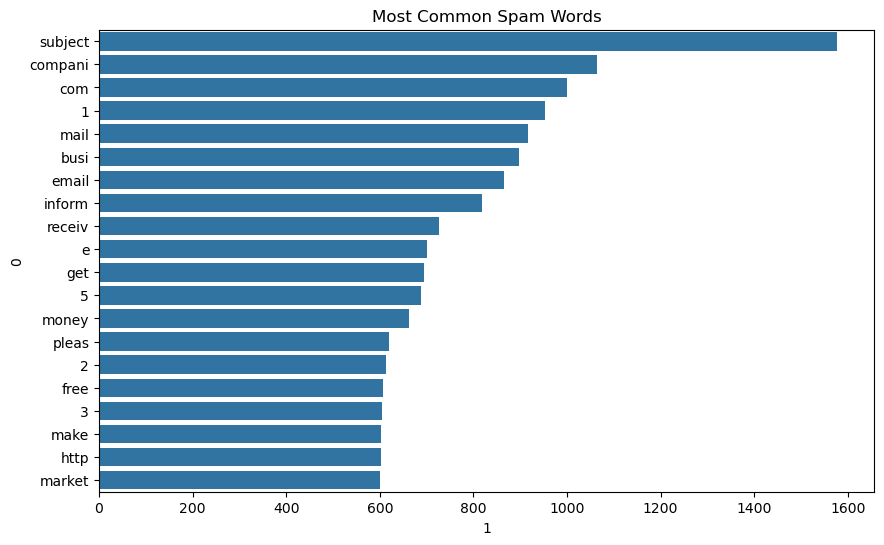

In [48]:
common_spam = pd.DataFrame(Counter(spam_words).most_common(20))

plt.figure(figsize=(10,6))

sns.barplot(x=common_spam[1],y=common_spam[0])

plt.title("Most Common Spam Words")

plt.show()

In [49]:
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [51]:
spam_wc = wc.generate(df[df['spam'] == 1]['transformed_text'].str.cat(sep=" "))

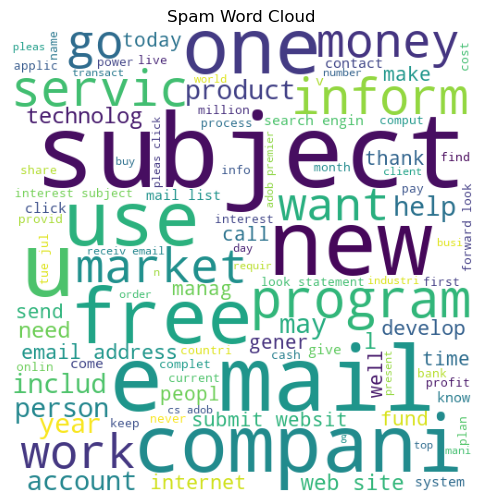

In [52]:
plt.figure(figsize=(12,6))

plt.imshow(spam_wc)

plt.axis("off")

plt.title("Spam Word Cloud")

plt.show()

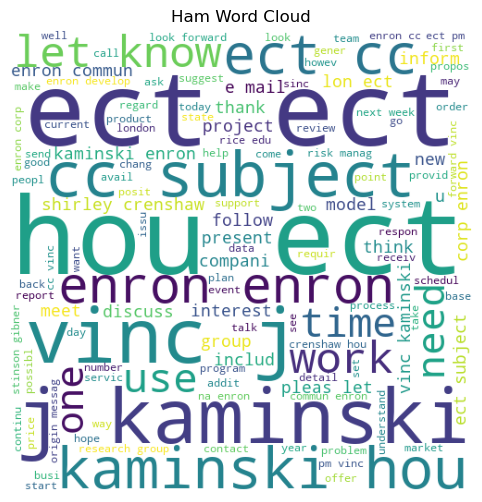

In [53]:
ham_wc = wc.generate(
    df[df['spam'] == 0]['transformed_text'].str.cat(sep=" ")
)

plt.figure(figsize=(12,6))

plt.imshow(ham_wc)

plt.axis("off")

plt.title("Ham Word Cloud")

plt.show()

# TF-IDF Vectorization
converting text data into numerical vectors using TF-IDF

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [130]:
x = df['transformed_text']
y = df['spam']

In [131]:
tfidf = TfidfVectorizer(max_features=3000)

In [132]:
x = tfidf.fit_transform(x).toarray()

In [69]:
x.shape

(5695, 3000)

# train test split
splitting the dataset into training and testing sets

In [82]:
from sklearn.model_selection import train_test_split

In [83]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Model Training

In [84]:
from sklearn.naive_bayes import MultinomialNB

In [93]:
mnb = MultinomialNB(alpha=0.1)

In [94]:
mnb.fit(x_train, y_train)

MultinomialNB(alpha=0.1)

In [95]:
y_pred = mnb.predict(x_test)
y_pred

array([0, 1, 0, ..., 0, 1, 1])

# Model Evaluation

In [97]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [99]:
print("Accuracy :",accuracy_score(y_test,y_pred))

print("Precision :",precision_score(y_test,y_pred))

print("Recall :",recall_score(y_test,y_pred))

print("F1 Score :",f1_score(y_test,y_pred))

Accuracy : 0.9868305531167691
Precision : 0.9895470383275261
Recall : 0.9594594594594594
F1 Score : 0.9742710120068611


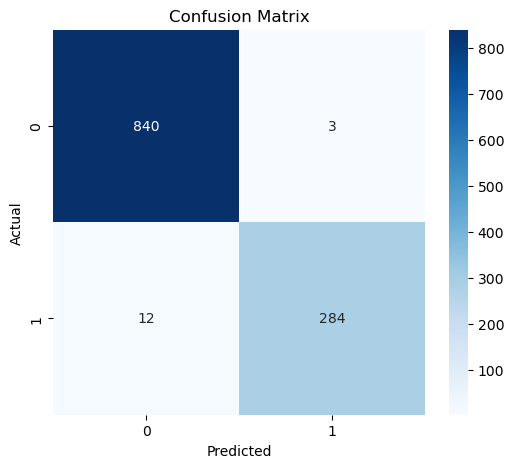

In [100]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [150]:
# function for spam prediction

def predict_spam(msg):

    transformed_msg = transform_text(msg)

    vector_input = tfidf.transform([transformed_msg])

    result = mnb.predict(vector_input)[0]

    if result == 1:
        print("Spam")
    else:
        print("Not Spam")

In [138]:
predict_spam("Win cash prize now!!!")

Spam


In [135]:
predict_spam("You have won a $1000 Walmart gift card. Claim now!")

Spam


In [136]:
predict_spam("Hey, are we still meeting for lunch tomorrow?")

Not Spam


# Saving Model

In [143]:
import pickle

In [144]:
pickle.dump(tfidf,open('vectorizer.pkl', 'wb'))

In [145]:
pickle.dump(mnb,open('model.pkl', 'wb'))